In [5]:
import sys
import os
from metient.metient import *
from metient.util import data_extraction_util as dutil

REPO_DIR = os.path.join(os.getcwd(), "metient")
TRACERX_DATA_DIR = os.path.join(REPO_DIR, 'data/tracerx_nsclc/')
INPUT_DIR = os.path.join(TRACERX_DATA_DIR, 'tracerx_provided_patient_data', )
OUTPUT_DIR = os.path.join(TRACERX_DATA_DIR, "metient_outputs", "test")

def run_conipher_patient(patient, weights):
    space = "x"*44
    tsv_fn = os.path.join(INPUT_DIR, f"{patient}_SNVs.tsv")
    print(tsv_fn)
    print(f"{space} PATIENT {patient} {space}")
    tree_fn = os.path.join(INPUT_DIR, f"{patient}_tree.txt")
    tree = dutil.get_adjacency_matrix_from_txt_edge_list(tree_fn)
    print_config = PrintConfig(visualize=True, verbose=False, k_best_trees=30)
    evaluate_label_clone_tree(tree, tsv_fn, weights, print_config, OUTPUT_DIR, patient, O=None,
                              solve_polytomies=True, sample_size=64)
    

/lila/data/morrisq/divyak/projects/metient/metient/data/tracerx_nsclc/tracerx_provided_patient_data/CRUK0010_SNVs.tsv
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx PATIENT CRUK0010 xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
/lila/data/morrisq/divyak/projects/metient/metient/data/tracerx_nsclc/tracerx_provided_patient_data/CRUK0010_SNVs.tsv
O: None
Tumor samples: ['primary_SU_T1', 'LN_SU_FLN1', 'metachronousMet_BR_LN1', 'metachronousMet_BR_LN2', 'metachronousMet_BR_LN3']


  1%|          | 20/2800 [00:22<51:01,  1.10s/it]


/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|██████████| 2800/2800 [03:25<00:00, 10.94it/s] 

Number of Pareto-optimal solutions: 1
CRUK0010_primary_SU_T1


<Figure size 640x480 with 0 Axes>

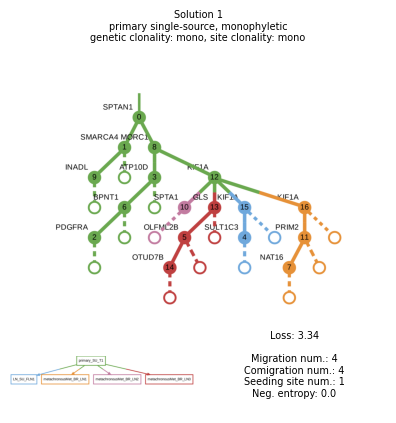

         1969251 function calls (1925419 primitive calls) in 208.521 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2800   81.090    0.029   81.090    0.029 {method 'run_backward' of 'torch._C._EngineBase' objects}
    16800   75.030    0.004   75.030    0.004 {method 'max' of 'torch._C._TensorBase' objects}
     2863   20.074    0.007   41.233    0.014 vertex_labeling_util.py:431(ancestral_labeling_metrics)
     2863   19.762    0.007   19.762    0.007 {built-in method torch.bmm}
     7500    1.696    0.000    1.696    0.000 {method 'acquire' of '_thread.lock' objects}
     3896    0.786    0.000    0.786    0.000 socket.py:621(send)
       14    0.571    0.041    0.571    0.041 {method 'read' of '_io.BufferedReader' objects}
     2700    0.332    0.000    0.446    0.000 vertex_labeling_util.py:548(stack_fixed_labeling)
       16    0.329    0.021    0.330    0.021 {built-in method matplotlib._image.resample}
     28

100%|██████████| 2800/2800 [03:41<00:00, 10.94it/s]

In [6]:
%%prun
weights = Weights()
run_conipher_patient("CRUK0010", weights)

In [ ]:

tracerx_reported_counts = {
    "Brain":6, "Chest wall":1, "Bronchus":4,"Pleura":2,"Rib":2,
    "Liver":6,"Flank":1,"Femur":1,"Neck LN":2,"Primary LN":148,
    "Recurrence LN":20,"Scapula":1,"Axillary LN":1,"Recurrence lung":13,
    "Primary surgery satellite lesion lung":3, "Adrenal gland":1,
    "Subphrenic mass":1, "Skin":3, "Paravertebral":1, "Peritoneum":1,
    "Lung":0
}

total = sum([tracerx_reported_counts[key] for key in tracerx_reported_counts])
tracerx_reported_freqs = {key:float(tracerx_reported_counts[key]/total) for key in tracerx_reported_counts}
print(tracerx_reported_freqs)
def get_organotropism_matrix_from_tracerx(unique_sites, tracerx_map):
    mapped_sites = [tracerx_map[site] for site in unique_sites]
    organotrop_arr = np.zeros(len(mapped_sites))
    for i, metastatic_site in enumerate(mapped_sites):
        organotrop_arr[i] = tracerx_reported_freqs[metastatic_site]
    return torch.tensor(organotrop_arr, dtype = torch.float32)


In [ ]:
import pandas as pd
no_cna_dir = os.path.join(TRACERX_DATA_DIR, "CRUK0762_no_cna_testing")
dutil.pool_input_tsv(os.path.join(no_cna_dir, "CRUK0762_SNVs.tsv"), no_cna_dir, f"tmp_CRUK0762")
df = pd.read_csv(os.path.join(no_cna_dir,"tmp_CRUK0762_clustered_SNVs.tsv"),sep="\t")
df['implied F no CNA'] = df.apply(lambda row: row['var']/(0.5*row['ref']+row['var']), axis=1)
df = df[['anatomical_site_label', 'cluster_index', 'implied F no CNA']]
matrix_df = df.pivot(index='cluster_index', columns='anatomical_site_label', values='implied F no CNA')
matrix_df.to_csv(os.path.join(no_cna_dir,"CRUK0762_clustered_SNVs_no_cnas.tsv"), sep="\t")


In [ ]:
df